<a href="https://colab.research.google.com/github/chicknco12/salary-determinants-ml/blob/main/Final-results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📂 Please upload your salary_dataset.csv file:


Saving Salary_Data (1).csv to Salary_Data (1).csv

Loaded dataset:
Removed 5 rows with NaN values in 'Salary'.


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
count,6699.000000,6699,6699,6699,6699.000000,6699.000000
unique,NaN,3,7,191,NaN,NaN
top,NaN,Male,Bachelor'S Degree,Software Engineer,NaN,NaN
freq,NaN,3672,2265,518,NaN,NaN
mean,33.622033,NaN,NaN,NaN,8.095014,115326.964771
std,7.615646,NaN,NaN,NaN,6.059853,52786.183911
min,21.000000,NaN,NaN,NaN,0.000000,350.000000
25%,28.000000,NaN,NaN,NaN,3.000000,70000.000000
50%,32.000000,NaN,NaN,NaN,7.000000,115000.000000
75%,38.000000,NaN,NaN,NaN,12.000000,160000.000000


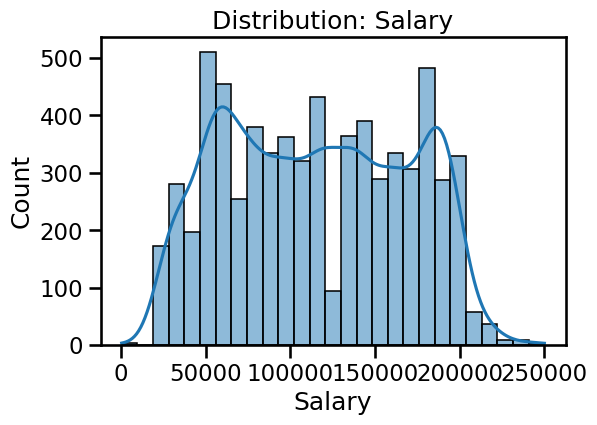

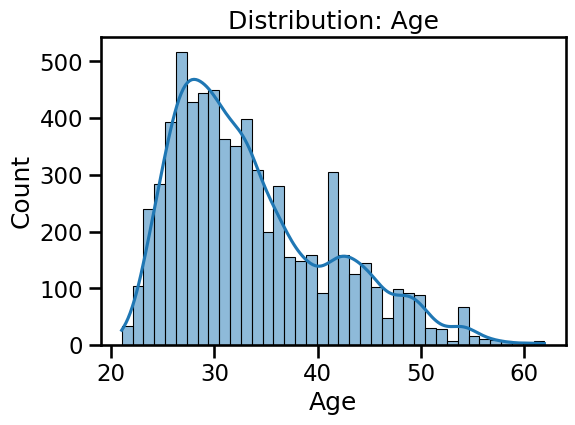

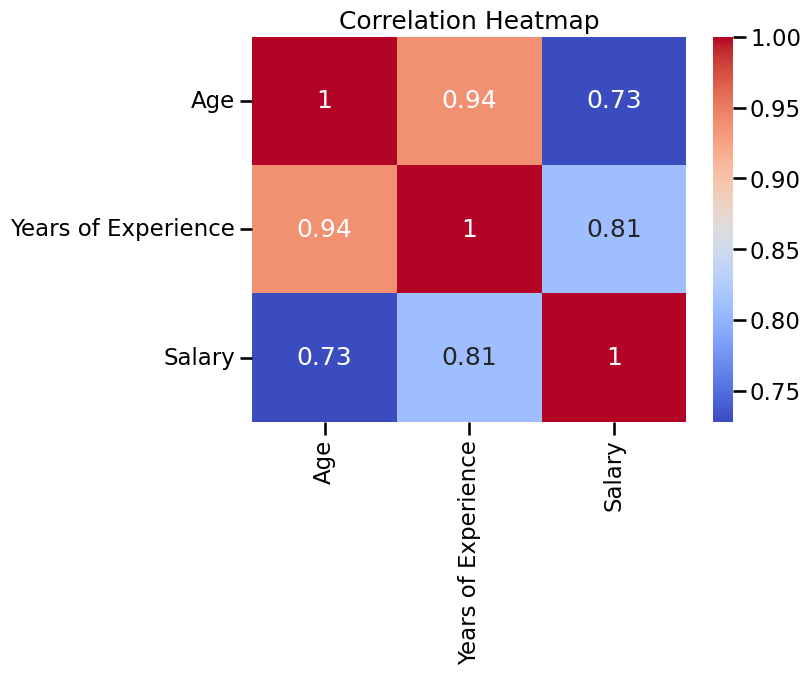

,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
0,Dummy (Mean),52789.171882,602.754916,45746.426426,744.709589,-0.001130,0.001285
1,Linear Regression,36120.586709,587.093196,28760.623246,331.431052,0.530987,0.018560
2,Random Forest,34285.451319,531.410267,26043.156652,397.489510,0.577416,0.016797
3,Gradient Boosting,34451.191078,560.449194,26332.471647,395.362675,0.573277,0.018261



🏆 Best model based on RMSE: Random Forest

🔍 Running SHAP...


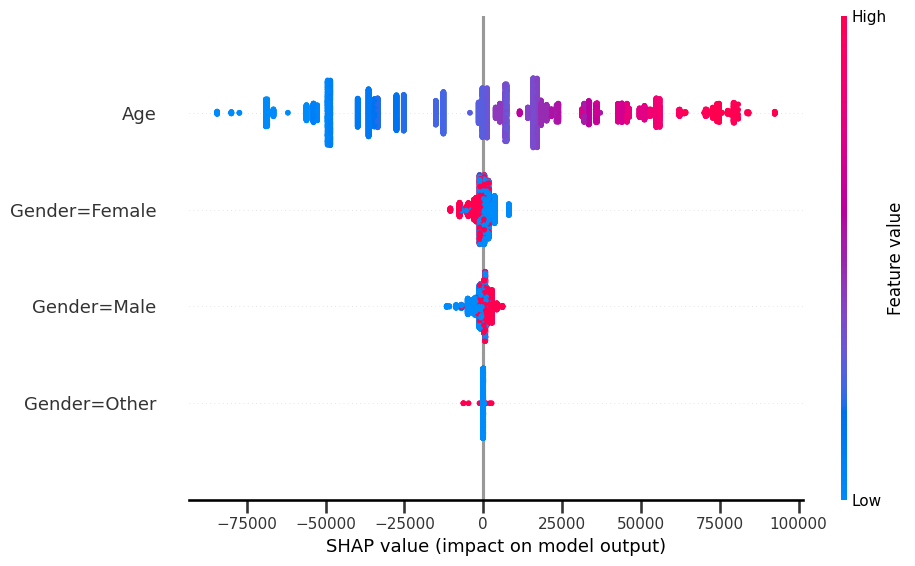


📊 Linear Coefficients:


,Feature,Coefficient
0,Age,38197.228241
2,Gender=Male,8633.118471
1,Gender=Female,4111.429497
3,Gender=Other,-12744.547968


,Feature,Coefficient
0,Age,38197.228241
2,Gender=Male,8633.118471
1,Gender=Female,4111.429497
3,Gender=Other,-12744.547968


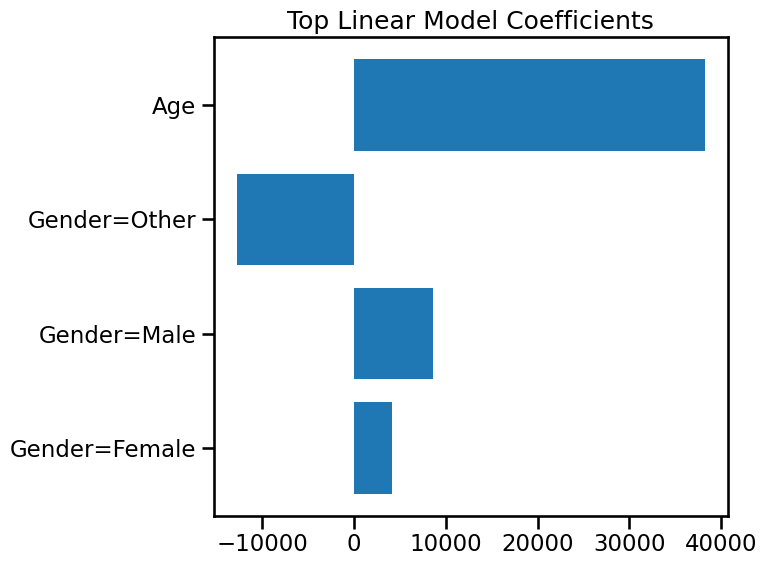


💬 Business Interpretation:
- Mean Absolute Error (MAE): ±$26,043
- This represents typical salary prediction error.
- This error margin can be used to define salary band ranges and budgeting buffers.


In [2]:
# -------------------------------------------------------------
# 1. SETUP: Install packages, set seeds, capture environment
# -------------------------------------------------------------
!pip install shap --quiet

import os, sys, random, platform, json, datetime, warnings
import numpy as np
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("talk")

from google.colab import files


# -------------------------------------------------------------
# 2. UPLOAD DATASET
# -------------------------------------------------------------
print("📂 Please upload your salary_dataset.csv file:")
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
print("\nLoaded dataset:")
df.head()


# -------------------------------------------------------------
# 3. BASIC CLEANING & EDA
# -------------------------------------------------------------

# Clean text columns
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip().str.title()

# Drop rows with NaN in the target column
if "Salary" in df.columns:
    initial_rows = len(df)
    df.dropna(subset=["Salary"], inplace=True)
    if len(df) < initial_rows:
        print(f"Removed {initial_rows - len(df)} rows with NaN values in 'Salary'.")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Summary
display(df.describe(include="all"))

# Plot numeric distributions
for col in ["Salary", "Yearsexperience", "Age"]:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution: {col}")
        plt.show()

# Correlation heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# -------------------------------------------------------------
# 4. PREPROCESSING: ColumnTransformer + Pipeline
# -------------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Define schema
target = "Salary"

numeric_features = [c for c in ["Age","Yearsexperience"] if c in df.columns]
categorical_features = [c for c in ["Gender","Education","Jobtitle","Location"] if c in df.columns]

X = df[numeric_features + categorical_features].copy()
y = df[target].copy()

# Explicit education categories
education_cats = [["High School","Bachelor","Master","Phd","Other"]]

# Build ColumnTransformer
transformers = [
    ("num", StandardScaler(), numeric_features)
]

for c in categorical_features:
    if c == "Education":
        transformers.append(
            (f"cat_{c}", OneHotEncoder(categories=education_cats, handle_unknown="ignore", sparse_output=False), [c])
        )
    else:
        transformers.append(
            (f"cat_{c}", OneHotEncoder(handle_unknown="ignore", sparse_output=False), [c])
        )

preprocessor = ColumnTransformer(transformers)


# -------------------------------------------------------------
# 5. MODELS + BASELINE + CROSS-VALIDATION
# -------------------------------------------------------------
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    "rmse": make_scorer(rmse, greater_is_better=False),
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "r2": make_scorer(r2_score)
}

models = {
    "Dummy (Mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
}

results = []
for name, model in models.items():
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    cv_res = cross_validate(pipe, X, y, cv=kfold, scoring=scoring)

    rmse_scores = -cv_res["test_rmse"]
    mae_scores  = -cv_res["test_mae"]
    r2_scores   =  cv_res["test_r2"]

    results.append({
        "Model": name,
        "RMSE_mean": rmse_scores.mean(),
        "RMSE_std": rmse_scores.std(),
        "MAE_mean": mae_scores.mean(),
        "MAE_std": mae_scores.std(),
        "R2_mean": r2_scores.mean(),
        "R2_std": r2_scores.std()
    })

metrics_df = pd.DataFrame(results)
display(metrics_df)


# -------------------------------------------------------------
# 6. FIT BEST MODEL ON FULL DATA FOR SHAP & COEFFICIENTS
# -------------------------------------------------------------
best_model_name = metrics_df.sort_values("RMSE_mean").iloc[0]["Model"]
print(f"\n🏆 Best model based on RMSE: {best_model_name}")

pipe_rf = Pipeline([("pre", preprocessor), ("model", RandomForestRegressor(n_estimators=300, random_state=SEED))])
pipe_lr = Pipeline([("pre", preprocessor), ("model", LinearRegression())])

pipe_rf.fit(X, y)
pipe_lr.fit(X, y)


# -------------------------------------------------------------
# 7. SHAP INTERPRETABILITY (AUTO-SKIP IF NOT SUPPORTED)
# -------------------------------------------------------------
print("\n🔍 Running SHAP...")

try:
    import shap

    # Compute SHAP
    explainer = shap.TreeExplainer(pipe_rf.named_steps["model"])
    X_transformed = pipe_rf.named_steps["pre"].transform(X)

    # Infer feature names
    feature_names = []
    feature_names.extend(numeric_features)

    for name, trans, cols in pipe_rf.named_steps["pre"].transformers_:
        if name.startswith("cat_"):
            oh = trans
            col = cols[0]
            cats = oh.categories_[0]
            feature_names.extend([f"{col}={c}" for c in cats])

    shap_values = explainer.shap_values(X_transformed)

    shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, plot_size=(10,6))
except Exception as e:
    print("⚠️ SHAP not supported in this environment:", e)


# -------------------------------------------------------------
# 8. LINEAR MODEL COEFFICIENTS
# -------------------------------------------------------------
print("\n📊 Linear Coefficients:")
pre = pipe_lr.named_steps["pre"]
lr = pipe_lr.named_steps["model"]

feature_names_lr = []

feature_names_lr.extend(numeric_features)

for name, trans, cols in pre.transformers_:
    if name.startswith("cat_"):
        oh = trans
        col = cols[0]
        cats = oh.categories_[0]
        feature_names_lr.extend([f"{col}={c}" for c in cats])

coef_df = pd.DataFrame({
    "Feature": feature_names_lr,
    "Coefficient": lr.coef_.ravel()
}).sort_values("Coefficient", ascending=False)

display(coef_df.head(10))
display(coef_df.tail(10))

plt.figure(figsize=(8,6))
coef_df["abs_coef"] = coef_df["Coefficient"].abs()
top = coef_df.sort_values("abs_coef", ascending=False).head(15)
plt.barh(top["Feature"][::-1], top["Coefficient"][::-1])
plt.title("Top Linear Model Coefficients")
plt.tight_layout()
plt.show()


# -------------------------------------------------------------
# 9. BUSINESS INTERPRETATION OF MAE
# -------------------------------------------------------------
best_mae = metrics_df.loc[metrics_df["Model"] == best_model_name]["MAE_mean"].values[0]
print(f"\n💬 Business Interpretation:")
print(f"- Mean Absolute Error (MAE): ±${best_mae:,.0f}")
print("- This represents typical salary prediction error.")
print("- This error margin can be used to define salary band ranges and budgeting buffers.")


In [3]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=metrics_df)

https://docs.google.com/spreadsheets/d/16aqtm7ehdDMJyl8ed9Wuyw8rhMTObIhOM2rAXnR1PlM/edit#gid=0
